<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_07_dataset_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"diabatyoussouf","key":"b34baefc19058d11590142f7dcc133d0"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# 1. Téléchargement du fichier zip depuis Kaggle
!kaggle datasets download -d shrutimechlearn/churn-modelling

# 2. Dézippage automatique
!unzip churn-modelling.zip

print(" Dataset téléchargé et prêt !")

Dataset URL: https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling
License(s): unknown
100% 262k/262k [00:00<00:00, 98.4MB/s]

Archive:  churn-modelling.zip
  inflating: Churn_Modelling.csv     
 Dataset téléchargé et prêt !


In [4]:
import pandas as pd

# Le fichier extrait s'appelle 'Churn_Modelling.csv'
churn_data = pd.read_csv('Churn_Modelling.csv')

print(f"Dimensions du dataset : {churn_data.shape}")
churn_data.head()

Dimensions du dataset : (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### **Objectif du Projet** : Modélisation du Churn Client

L'objectif de ce projet est de développer un modèle prédictif capable d'identifier la probabilité qu'un client quitte l'entreprise ($y = 1$) en fonction de ses attributs sociodémographiques et bancaires ($X$).

Mathématiquement, nous cherchons à estimer la fonction de prédiction :
$$\hat{y} = f(X)$$

Où :
* $X \in \mathbb{R}^{10000 \times 11}$ représente la matrice des variables explicatives (après exclusion des identifiants non prédictifs : `RowNumber`, `CustomerId` et `Surname`).
* $y \in \{0, 1\}^{10000}$ représente le vecteur cible binaire (`Exited`), où :
  * $0$ : Le client reste au sein de l'entreprise.
  * $1$ : Le client résilie son contrat (Churn).

Puisqu'il s'agit d'un problème de classification binaire, l'optimisation du modèle consistera à minimiser la fonction de perte de l'entropie croisée binaire (Log-Loss) :
$$\mathcal{L}(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Analyse Exploratoire**

### **La variable cible `Exited`**

In [5]:
df = churn_data.copy()

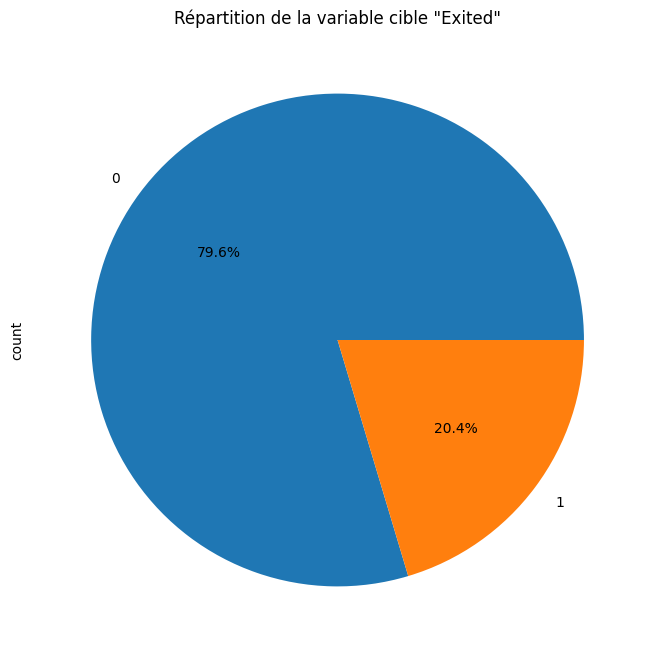

In [10]:
df['Exited'].value_counts().plot.pie(figsize=(8, 8), autopct='%1.1f%%')
plt.title('Répartition de la variable cible "Exited"')
plt.show()

### **Les variables features**

In [16]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


La distribution de Gender

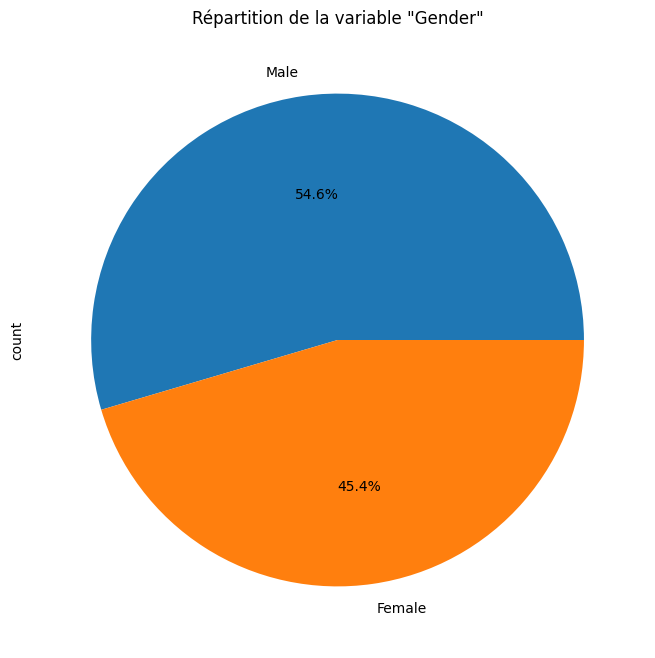

In [18]:
df['Gender'].value_counts().plot.pie(figsize=(8, 8), autopct='%1.1f%%')
plt.title('Répartition de la variable "Gender"')
plt.show()

churn par rapport gender

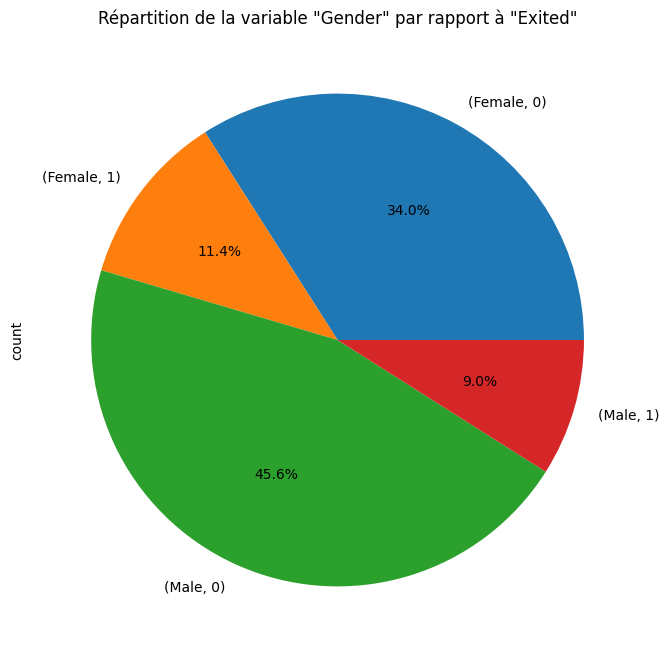

In [22]:
df['Exited'].groupby(df['Gender']).value_counts().plot.pie(figsize=(8, 8), autopct='%1.1f%%')
plt.title('Répartition de la variable "Gender" par rapport à "Exited"')
plt.show()

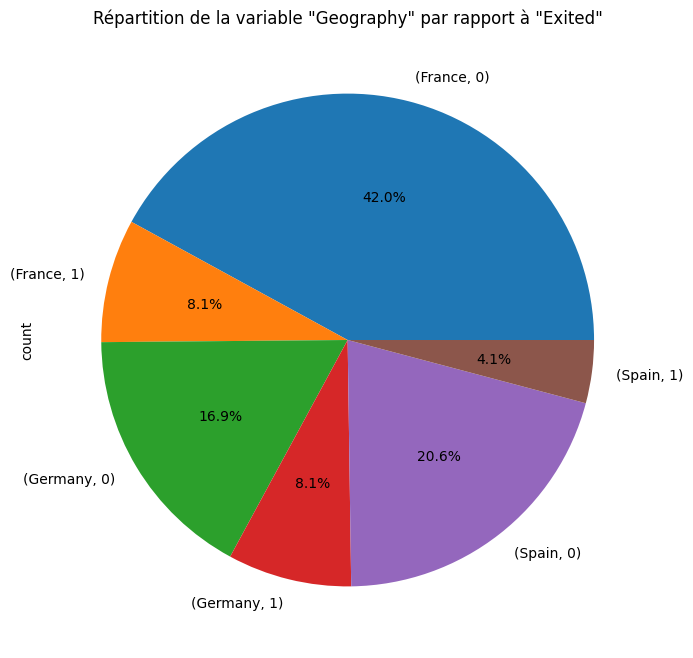

In [23]:
df['Exited'].groupby(df['Geography']).value_counts().plot.pie(figsize=(8, 8), autopct='%1.1f%%')
plt.title('Répartition de la variable "Geography" par rapport à "Exited"')
plt.show()

In [28]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


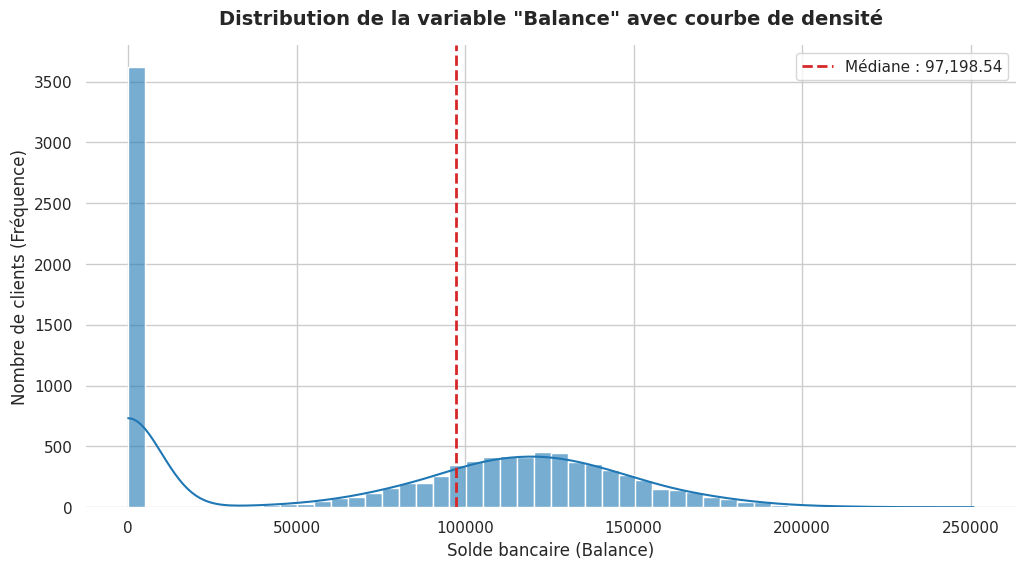

In [36]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histogramme moderne avec courbe de densité (KDE)
sns.histplot(
    data=churn_data,
    x="Balance",
    bins=50,
    kde=True,
    color="#1f77b4",
    alpha=0.6,
    edgecolor="white"
)

# Ajout d'une ligne verticale pour la médiane
mediane_balance = churn_data['Balance'].median()
plt.axvline(
    mediane_balance,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {mediane_balance:,.2f}"
)

# Habillage et titres professionnels
plt.title('Distribution de la variable "Balance" avec courbe de densité', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Solde bancaire (Balance)', fontsize=12)
plt.ylabel('Nombre de clients (Fréquence)', fontsize=12)
plt.legend(fontsize=11)

# Nettoyage des bordures pour un rendu épuré
sns.despine(left=True, bottom=True)

plt.show()

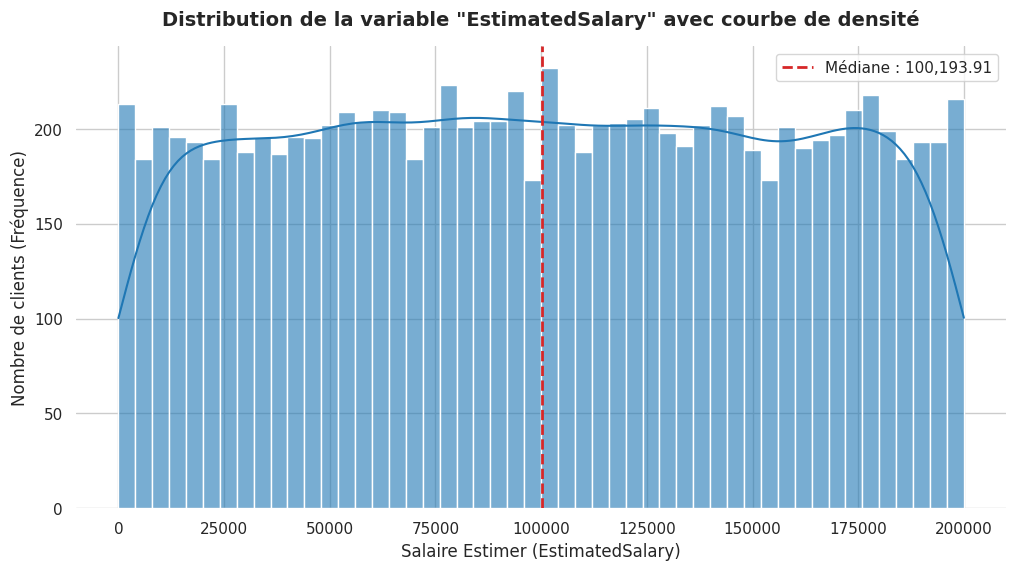

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histogramme moderne avec courbe de densité (KDE)
sns.histplot(
    data=churn_data,
    x="EstimatedSalary",
    bins=50,
    kde=True,
    color="#1f77b4",
    alpha = 0.6,
    edgecolor="white"
)

mediane_estimated_salary = churn_data['EstimatedSalary'].median()
plt.axvline(
    mediane_estimated_salary,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {mediane_estimated_salary:,.2f}"
)

plt.title('Distribution de la variable "EstimatedSalary" avec courbe de densité', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Salaire Estimer (EstimatedSalary)', fontsize=12)
plt.ylabel('Nombre de clients (Fréquence)', fontsize=12)
plt.legend(fontsize=11)

sns.despine(left=True, bottom=True)

plt.show()


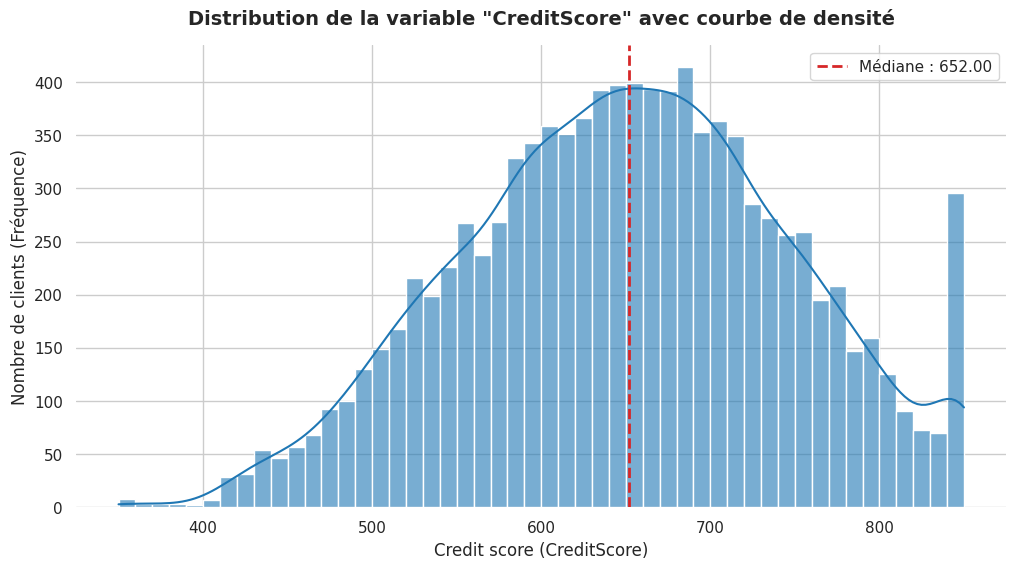

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histogramme moderne avec courbe de densité (KDE)
sns.histplot(
    data=churn_data,
    x="CreditScore",
    bins=50,
    kde=True,
    color="#1f77b4",
    alpha = 0.6,
    edgecolor="white"
)

mediane_credit_score = churn_data['CreditScore'].median()
plt.axvline(
    mediane_credit_score,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {mediane_credit_score:,.2f}"
)


plt.title('Distribution de la variable "CreditScore" avec courbe de densité', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Credit score (CreditScore)', fontsize=12)
plt.ylabel('Nombre de clients (Fréquence)', fontsize=12)
plt.legend(fontsize=11)

sns.despine(left=True, bottom=True)

plt.show()


# **2. Preprocessing**

In [42]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Variables numériques :", numeric_features.tolist())
print("Variables catégorielles :", categorical_features.tolist())

Variables numériques : ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Variables catégorielles : ['Surname', 'Geography', 'Gender']


### La correlation des variables numériques

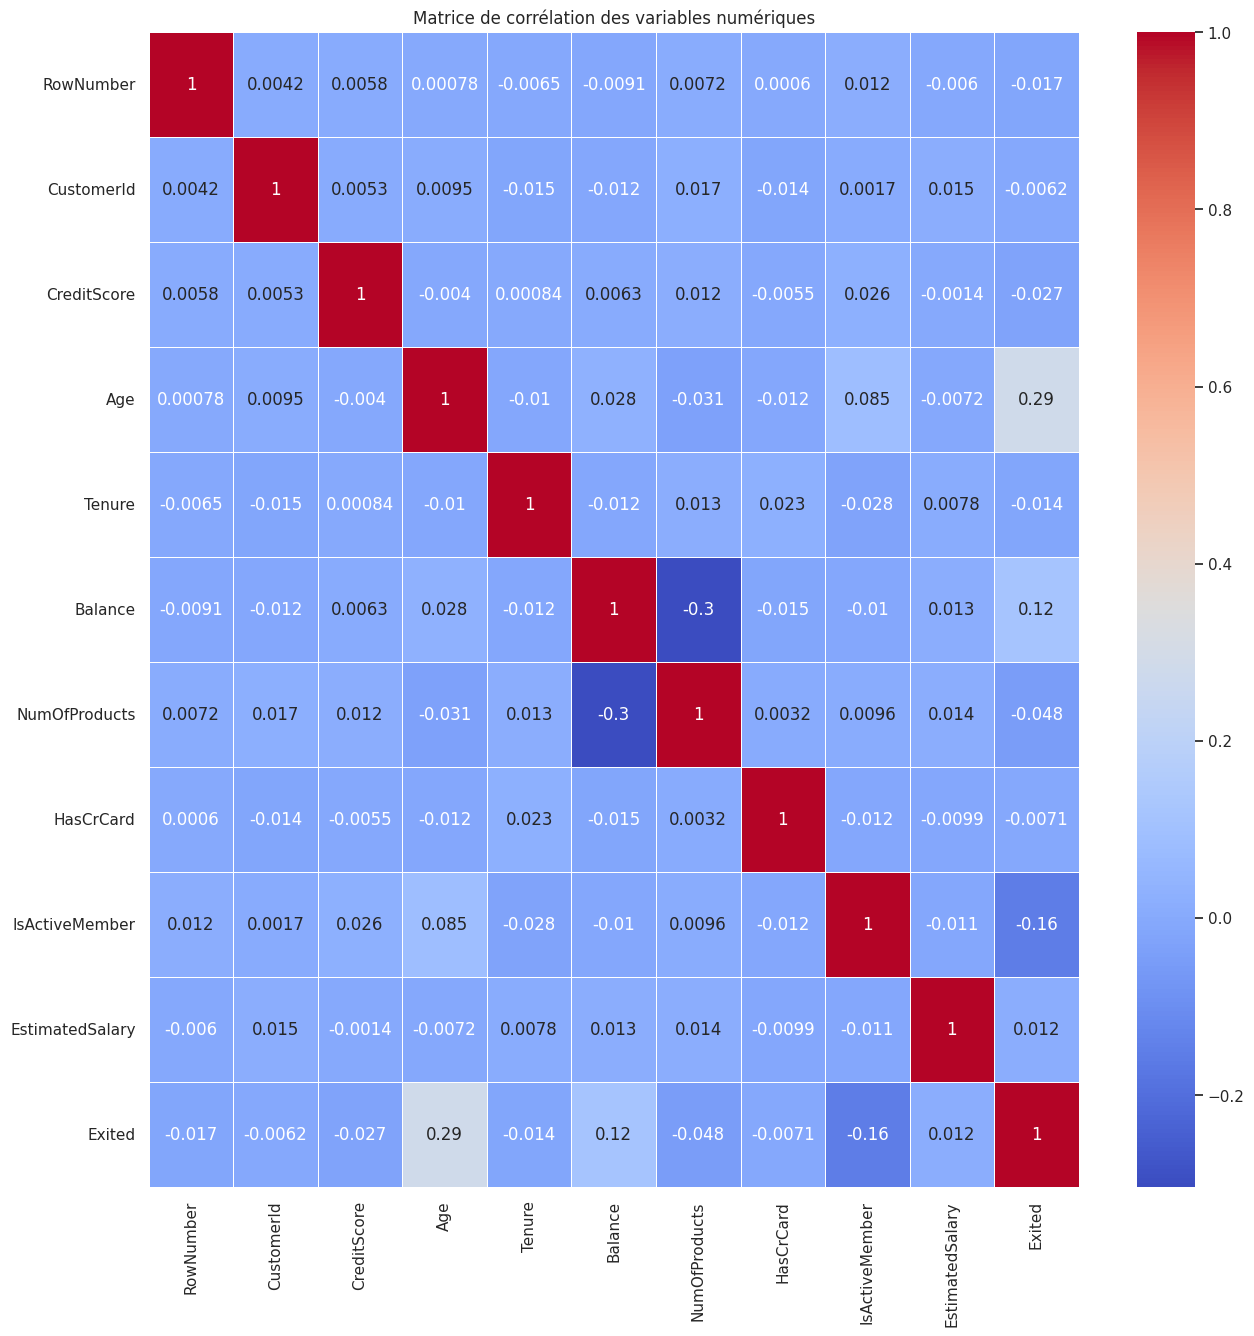

In [45]:
corr_num = df[numeric_features].corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

Les colonnes RowNumber et CustomerId ne contiennent aucune information necessaire pour notre modèle(ce sont les identifiants)

In [49]:
col_numeric_inutils = ["RowNumber", "CustomerId"]
df.drop(col_numeric_inutils, axis=1, inplace=True)

In [51]:
df[categorical_features].head()

,Surname,Geography,Gender
0,Hargrave,France,Female
1,Hill,Spain,Female
2,Onio,France,Female
3,Boni,France,Female
4,Mitchell,Spain,Female


In [52]:
# supprimer aussi la variable Surname identifier de famille afin d'éviter overfitting
df.drop(["Surname"],axis = 1,inplace=True)

In [53]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Encoder les variables categoriels

In [54]:
categorical_features = df.select_dtypes(include=['object']).columns
print("Variables catégorielles :", categorical_features.tolist())

Variables catégorielles : ['Geography', 'Gender']


In [57]:
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [58]:
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


### Split data

In [71]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [59]:
X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [64]:
print(" Données normalisées avec succès !")
X_train_scaled.head()

 Données normalisées avec succès !


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,-0.579467,-0.576388,0.913248
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,1.725723,-0.576388,0.913248
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,-0.579467,1.734942,0.913248
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,-0.579467,-0.576388,-1.094993
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,-0.579467,-0.576388,0.913248


In [66]:
# Calcul du ratio pour XGBoost (80% / 20% = ~4)
ratio_desequilibre = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialisation des modèles avec gestion du déséquilibre
models = {
    "Régression Logistique": LogisticRegression(class_weight='balanced', random_state=42),

    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),

    "SVM": SVC(class_weight='balanced', probability=True, random_state=42),

    "XGBoost": XGBClassifier(scale_pos_weight=ratio_desequilibre, random_state=42, eval_metric='logloss')
}

In [67]:
# Entraînement automatique dans une boucle
print(" Début de l'entraînement des modèles...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"   ↳ {name} entraîné avec succès !")

print("\nTous les modèles sont prêts pour l'évaluation !")

 Début de l'entraînement des modèles...
   ↳ Régression Logistique entraîné avec succès !
   ↳ Random Forest entraîné avec succès !
   ↳ SVM entraîné avec succès !
   ↳ XGBoost entraîné avec succès !

Tous les modèles sont prêts pour l'évaluation !


 RAPPORTS DE CLASSIFICATION (SUR LE TEST SET) 

================ Régression Logistique ================
              precision    recall  f1-score   support

   Reste (0)       0.91      0.72      0.81      1607
   Churn (1)       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000

================ Random Forest ================
              precision    recall  f1-score   support

   Reste (0)       0.88      0.97      0.92      1607
   Churn (1)       0.79      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

================ SVM ================
              precision    recall  f1-score   support

   Reste (0)       0.93      0.79      0.86      1607
   Churn (1)       0.47      0.75      0.58    

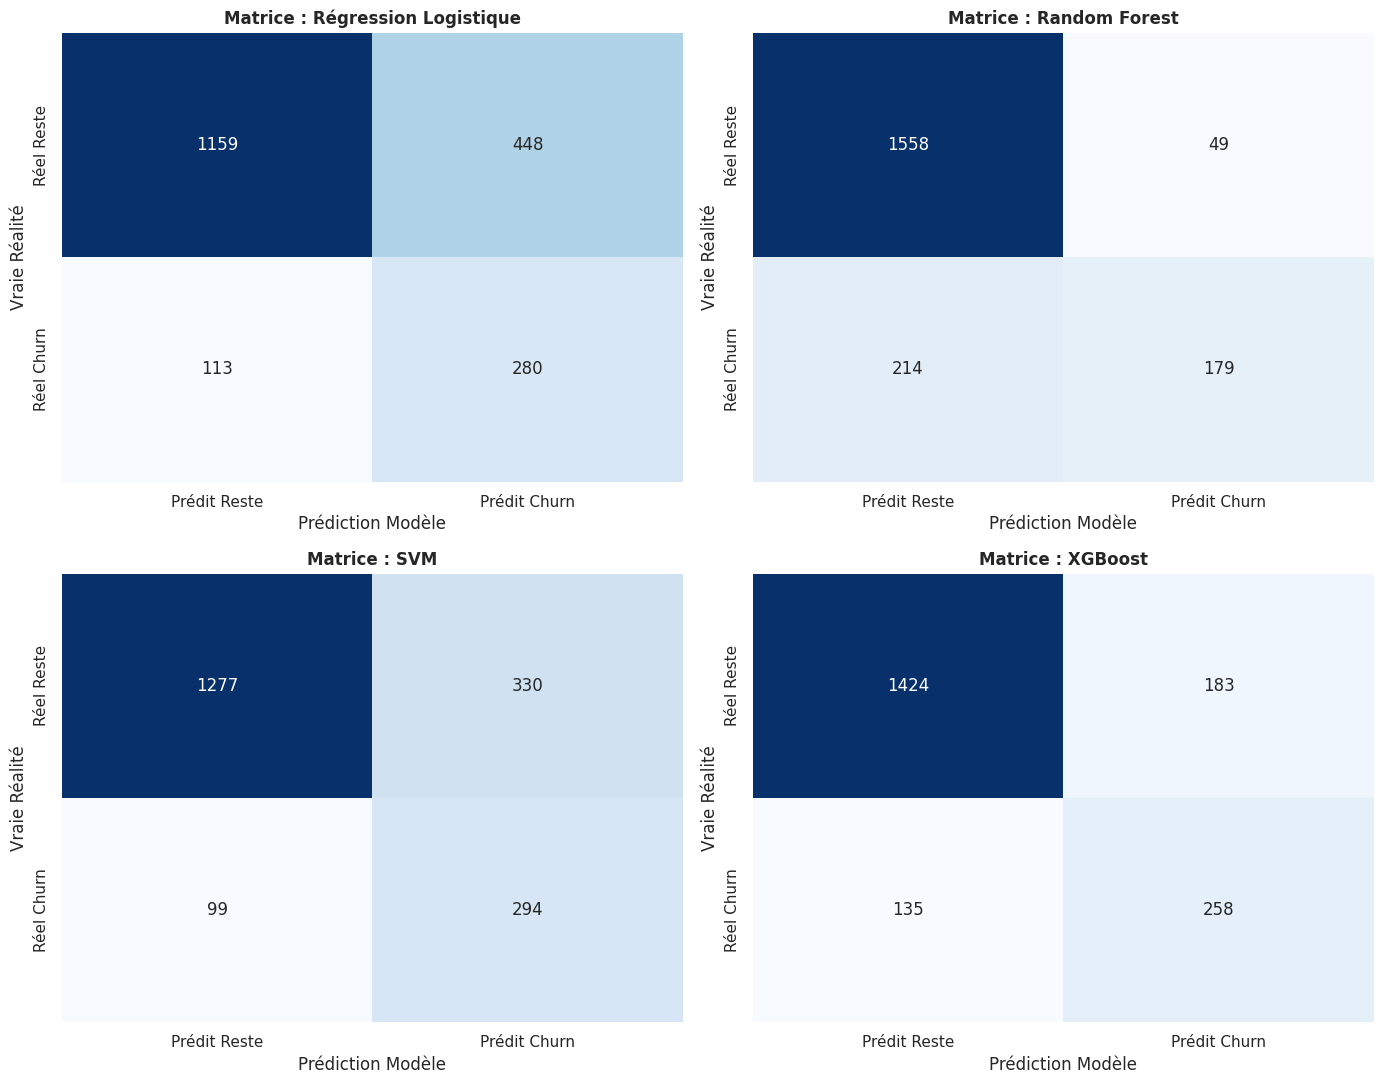

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

print(" RAPPORTS DE CLASSIFICATION (SUR LE TEST SET) \n")

for i, (name, model) in enumerate(models.items()):
    # Prédiction sur le Test mis à l'échelle
    y_pred = model.predict(X_test_scaled)

    # 2Affichage du rapport textuel dans la console
    print(f"================ {name} ================")
    print(classification_report(y_test, y_pred, target_names=['Reste (0)', 'Churn (1)']))

    # Calcul et affichage de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Prédit Reste', 'Prédit Churn'],
                yticklabels=['Réel Reste', 'Réel Churn'])
    axes[i].set_title(f"Matrice : {name}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Vraie Réalité')
    axes[i].set_xlabel('Prédiction Modèle')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1119/3070191334.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


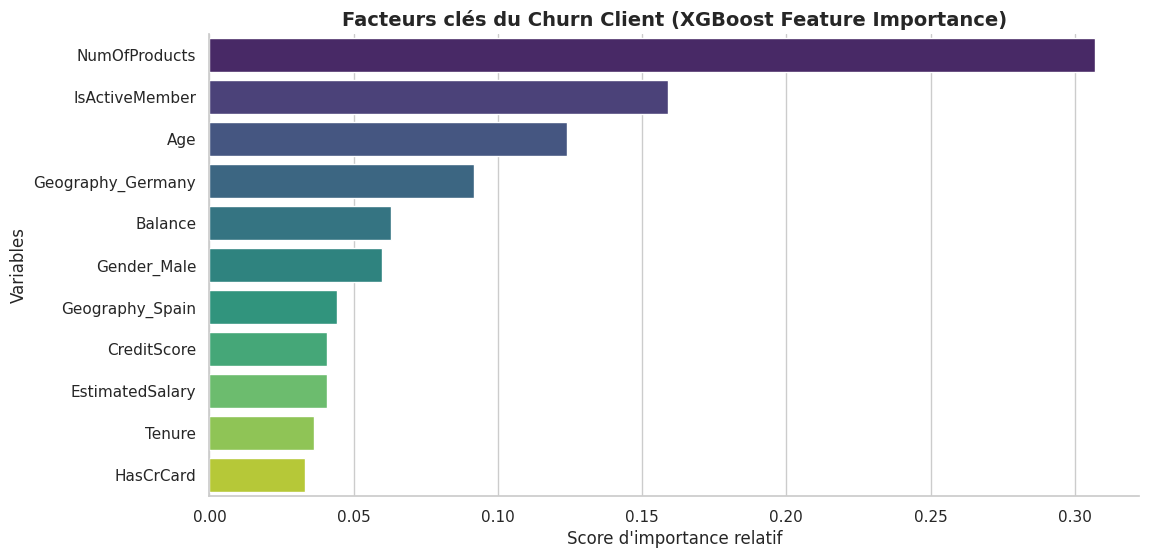

In [70]:
import numpy as np

# Récupération de l'importance des variables depuis XGBoost
importances = models["XGBoost"].feature_importances_
indices = np.argsort(importances)[::-1]

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Facteurs clés du Churn Client (XGBoost Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Score d'importance relatif")
plt.ylabel("Variables")
sns.despine()
plt.show()

# **Utilisation de gridSearch**

In [72]:
# Définition de la grille de paramètres à tester
param_grid = {
    'max_depth': [3, 5, 7],           # Profondeur de l'arbre (évite le surapprentissage)
    'learning_rate': [0.01, 0.1, 0.2], # Vitesse d'apprentissage
    'n_estimators': [100, 200],       # Nombre d'arbres à construire
    'subsample': [0.8, 1.0]           # Proportion de données utilisées par arbre
}

# Initialisation du modèle de base avec son poids pour le déséquilibre
xgb_base = XGBClassifier(scale_pos_weight=ratio_desequilibre, random_state=42, eval_metric='logloss')

#  Configuration du GridSearch (on cherche à maximiser le F1-score)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,       # Cross-validation en 3 blocs
    verbose=1,
    n_jobs=-1   # Utilise tous les processeurs disponibles
)

print(" Recherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train_scaled, y_train)

# Extraction du meilleur modèle
best_xgb = grid_search.best_estimator_
print(f"\n Meilleurs paramètres trouvés : {grid_search.best_params_}")

 Recherche des meilleurs hyperparamètres en cours...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

 Meilleurs paramètres trouvés : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}



 RAPPORT DE CLASSIFICATION (XGBOOST OPTIMISÉ) 
              precision    recall  f1-score   support

   Reste (0)       0.93      0.83      0.88      1607
   Churn (1)       0.52      0.75      0.62       393

    accuracy                           0.82      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.82      0.83      2000



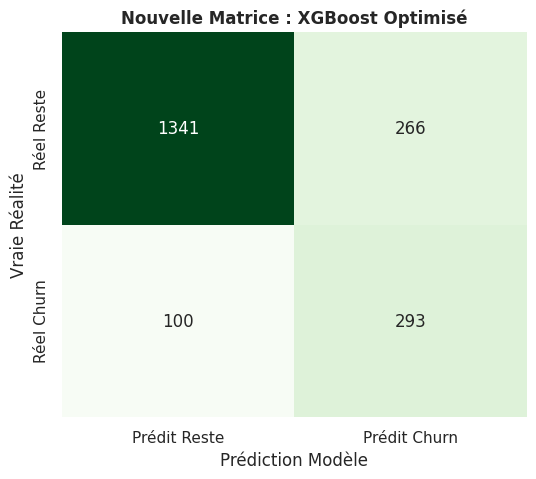

In [73]:
# Prédiction avec le modèle optimisé
y_pred_opt = best_xgb.predict(X_test_scaled)

# Affichage du nouveau rapport
print("\n RAPPORT DE CLASSIFICATION (XGBOOST OPTIMISÉ) ")
print(classification_report(y_test, y_pred_opt, target_names=['Reste (0)', 'Churn (1)']))

# Tracé de la nouvelle matrice de confusion
plt.figure(figsize=(6, 5))
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prédit Reste', 'Prédit Churn'],
            yticklabels=['Réel Reste', 'Réel Churn'], cbar=False)
plt.title("Nouvelle Matrice : XGBoost Optimisé", fontsize=12, fontweight='bold')
plt.ylabel('Vraie Réalité')
plt.xlabel('Prédiction Modèle')
plt.show()

 --- MATRICE AVEC SEUIL À 60.0% ---
              precision    recall  f1-score   support

   Reste (0)       0.92      0.89      0.91      1607
   Churn (1)       0.61      0.70      0.65       393

    accuracy                           0.85      2000
   macro avg       0.77      0.80      0.78      2000
weighted avg       0.86      0.85      0.86      2000



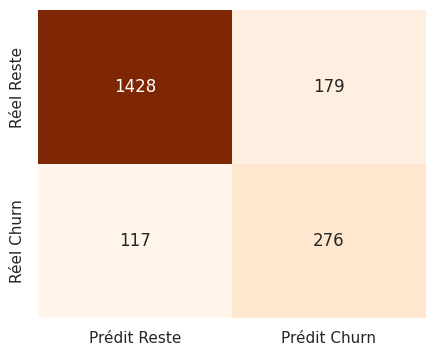

In [75]:
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

nouveau_seuil = 0.60
y_pred_custom = (y_proba >= nouveau_seuil).astype(int)

print(f" --- MATRICE AVEC SEUIL À {nouveau_seuil*100}% ---")
print(classification_report(y_test, y_pred_custom, target_names=['Reste (0)', 'Churn (1)']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit Reste', 'Prédit Churn'], yticklabels=['Réel Reste', 'Réel Churn'], cbar=False)
plt.show()